# フェーズ2：来店予測モデル（→売上予測）

フェーズ1で生成した擬似データ（`data/retail_synthetic.csv`）を使い、**翌日の来店客数** を予測します。
さらに来店予測から **売上予測（来店客数 × 客単価）** へ接続します。

## 流れ
1. **データ読み込み**
2. **特徴量エンジニアリング** … 予測時点（前日夜）で入手可能な情報のみ（データリーク対策）
3. **時系列分割** … 過去で学習 → 未来で検証
4. **来店予測モデル学習** … 勾配ブースティング（HistGradientBoostingRegressor）
5. **精度評価** … MAE / RMSE / MAPE ＋ 繁忙日誤差。ベースライン比較
6. **特徴量重要度** … 何が来店を動かすか
7. **売上予測への接続** … 来店予測 × 客単価予測

> 予測のしくみ：「翌日（target日）」の来店を、前日夜時点で分かる情報だけで予測します。
> - カレンダー・販促：未来でも確定（祝日、ポイント◯倍デー、特売予定など）
> - 天候：翌日の**予報値**を使用
> - 人流：翌日の**人流予測値**を使用
> - SNS：**前日まで**の言及数（当日値はまだ取れない＝リーク）
> - 来店：**過去**の来店実績ラグ

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

sys.path.append(str(Path.cwd() / "src"))

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP"]:
    if any(_f in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

print("セットアップ完了 / pandas", pd.__version__)

セットアップ完了 / pandas 3.0.3


## 1. データ読み込み

フェーズ1で保存した CSV を読み込みます。無い場合は生成モジュールから作成します。

In [2]:
csv_path = Path("data/retail_synthetic.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=["date"])
    print("CSVから読み込み:", csv_path)
else:
    from retail_synthetic_data import generate_retail_data
    df = generate_retail_data()
    print("生成モジュールから作成")

df = df.sort_values("date").reset_index(drop=True)
print("期間:", df["date"].min().date(), "〜", df["date"].max().date(), "／", len(df), "日")
df.head()

CSVから読み込み: data/retail_synthetic.csv
期間: 2024-01-01 〜 2025-12-30 ／ 730 日


,date,visitors,sales_amount,avg_spend,member_visitors,member_ratio,new_member_ratio,repeat_ratio,temp_max,temp_min,precipitation_mm,weather,foot_traffic,sns_mentions,sns_sentiment,point_multiplier,is_sale,coupon_sent,is_holiday,is_weekend,is_payday
0,2024-01-01,686,1820644,2654,402,0.586,0.064,0.936,11.0,1.2,0.0,cloudy,8403,218,0.517,1,0,0,1,0,0
1,2024-01-02,534,1427382,2673,337,0.631,0.092,0.908,8.9,0.5,0.0,sunny,6705,238,0.553,1,0,0,0,0,0
2,2024-01-03,535,1372810,2566,335,0.626,0.062,0.938,11.5,1.2,0.0,sunny,6902,221,0.610,1,0,0,0,0,0
3,2024-01-04,635,1581150,2490,396,0.624,0.060,0.940,11.8,0.1,0.0,cloudy,6629,299,0.556,1,0,0,0,0,0
4,2024-01-05,711,1903347,2677,462,0.650,0.055,0.945,7.4,0.7,0.0,cloudy,8862,463,0.671,5,0,0,0,0,0


## 2. 特徴量エンジニアリング（リーク対策）

「翌日（target日）の来店客数」を予測するため、**予測時点（前日夜）で入手可能な情報だけ**を特徴量にします。

| 種類 | 使う列 | 入手可能な理由 |
|---|---|---|
| カレンダー | 曜日・月・祝日・週末・給料日 | 未来でも確定 |
| 販促 | ポイント倍率・特売・クーポン | 販促は事前計画済み |
| 天候（予報） | 気温・降水・天気 | 翌日予報が前日に入手可能 |
| 人流（予測） | foot_traffic | 人流“予測”値として入手可能 |
| SNS（前日まで） | sns_lag1 / 移動平均 | 当日値は予測時点で未取得 |
| 来店ラグ | 1日前・7日前・前年同日・移動平均 | 過去実績 |

In [3]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy().sort_values("date").reset_index(drop=True)
    dt = d["date"].dt

    # --- カレンダー（target日。確定情報）---
    d["dow"] = dt.dayofweek
    d["month"] = dt.month
    d["weekofyear"] = dt.isocalendar().week.astype(int)
    # is_weekend / is_holiday / is_payday は生成済み列をそのまま使用

    # --- 天候（target日の予報値）派生 ---
    d["rain_flag"] = (d["precipitation_mm"] >= 1.0).astype(int)
    d["heavy_rain_flag"] = (d["precipitation_mm"] >= 20.0).astype(int)
    d["comfortable_temp"] = ((d["temp_max"] >= 20) & (d["temp_max"] <= 26)).astype(int)
    d["temp_range"] = d["temp_max"] - d["temp_min"]

    # --- SNS（前日まで＝1日シフト。当日値は使わない）---
    d["sns_lag1"] = d["sns_mentions"].shift(1)
    d["sns_ma3"] = d["sns_mentions"].shift(1).rolling(3).mean()
    d["sns_ma7"] = d["sns_mentions"].shift(1).rolling(7).mean()
    d["sns_surge"] = (d["sns_lag1"] > d["sns_ma7"] * 1.2).astype(int)

    # --- 来店ラグ（過去実績）---
    d["visitors_lag1"] = d["visitors"].shift(1)
    d["visitors_lag7"] = d["visitors"].shift(7)
    d["visitors_lag365"] = d["visitors"].shift(365)
    d["visitors_ma7"] = d["visitors"].shift(1).rolling(7).mean()
    d["visitors_ma30"] = d["visitors"].shift(1).rolling(30).mean()

    return d


FEATURES = [
    # カレンダー
    "dow", "month", "weekofyear", "is_weekend", "is_holiday", "is_payday",
    # 販促
    "point_multiplier", "is_sale", "coupon_sent",
    # 天候（予報値）
    "temp_max", "temp_min", "precipitation_mm", "rain_flag",
    "heavy_rain_flag", "comfortable_temp", "temp_range",
    # 人流（予測値）
    "foot_traffic",
    # SNS（前日まで）
    "sns_lag1", "sns_ma3", "sns_ma7", "sns_surge",
    # 来店ラグ（lag365は2年目以降のみ。欠損は勾配ブースティングが扱う）
    "visitors_lag1", "visitors_lag7", "visitors_lag365", "visitors_ma7", "visitors_ma30",
]
TARGET = "visitors"

df_feat = build_features(df)
# ラグ生成で先頭に NaN が出るため、前年同日以外の特徴が揃う行だけ残す
need = [c for c in FEATURES if c != "visitors_lag365"]
df_feat = df_feat.dropna(subset=need).reset_index(drop=True)
print("特徴量テーブル:", df_feat.shape, "／特徴量数:", len(FEATURES))
df_feat[["date", TARGET] + FEATURES].head()

特徴量テーブル: (700, 37) ／特徴量数: 26


,date,visitors,dow,month,weekofyear,is_weekend,is_holiday,is_payday,point_multiplier,is_sale,coupon_sent,temp_max,temp_min,precipitation_mm,rain_flag,heavy_rain_flag,comfortable_temp,temp_range,foot_traffic,sns_lag1,sns_ma3,sns_ma7,sns_surge,visitors_lag1,visitors_lag7,visitors_lag365,visitors_ma7,visitors_ma30
0,2024-01-31,646,2,1,5,0,0,1,1,0,0,13.5,2.1,0.0,0,0,0,11.4,10402,288.0,241.666667,301.571429,0,657.0,664.0,NaN,793.714286,706.666667
1,2024-02-01,391,3,2,5,0,0,0,1,0,1,9.7,1.2,19.1,1,0,0,8.5,4839,142.0,223.333333,291.714286,0,646.0,722.0,NaN,791.142857,705.333333
2,2024-02-02,736,4,2,5,0,0,0,1,0,0,9.6,1.4,0.0,0,0,0,8.2,10374,364.0,264.666667,289.142857,1,391.0,819.0,NaN,743.857143,700.566667
3,2024-02-03,1121,5,2,5,1,0,0,1,1,0,9.2,1.3,0.0,0,0,0,7.9,10943,456.0,320.666667,310.857143,1,736.0,889.0,NaN,732.000000,707.266667
4,2024-02-04,1039,6,2,5,1,0,0,1,1,0,11.4,0.9,5.2,1,0,0,10.5,10895,502.0,440.666667,312.714286,1,1121.0,1227.0,NaN,765.142857,723.466667


## 3. 時系列分割

直近90日を検証期間、それより前を学習期間とします（ランダム分割は禁止）。

In [4]:
TEST_DAYS = 90
split_idx = len(df_feat) - TEST_DAYS
train = df_feat.iloc[:split_idx]
test = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"学習: {train['date'].min().date()} 〜 {train['date'].max().date()}  ({len(train)}日)")
print(f"検証: {test['date'].min().date()} 〜 {test['date'].max().date()}  ({len(test)}日)")

学習: 2024-01-31 〜 2025-10-01  (610日)
検証: 2025-10-02 〜 2025-12-30  (90日)


## 4. 来店予測モデルの学習

In [5]:
visit_model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)
visit_model.fit(X_train, y_train)
pred_visit = visit_model.predict(X_test)
print("学習完了。木の数:", visit_model.n_iter_)

学習完了。木の数: 217


## 5. 精度評価（ベースライン比較）

機械学習を使わない単純な予測（ベースライン）と比較します。

- **ベースラインA**：前年同日（無ければ7日前）
- **ベースラインB**：直近7日の移動平均
- **ベースラインC**：曜日別の平均（学習期間の曜日平均）

評価指標は MAE / RMSE / MAPE ＋ **繁忙日（来店上位20%）に絞った MAPE**。

In [6]:
# ベースライン
base_a = test["visitors_lag365"].fillna(test["visitors_lag7"]).values
base_b = test["visitors_ma7"].values
dow_mean = train.groupby("dow")["visitors"].mean()
base_c = test["dow"].map(dow_mean).values


def evaluate(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    thr = np.quantile(y_true, 0.8)
    peak = y_true >= thr
    peak_mape = np.mean(np.abs((y_true[peak] - y_pred[peak]) / y_true[peak])) * 100
    return {"モデル": name, "MAE": mae, "RMSE": rmse, "MAPE(%)": mape, "繁忙日MAPE(%)": peak_mape}


results = pd.DataFrame([
    evaluate("勾配ブースティング(本命)", y_test, pred_visit),
    evaluate("ベースラインA(前年同日)", y_test, base_a),
    evaluate("ベースラインB(7日移動平均)", y_test, base_b),
    evaluate("ベースラインC(曜日平均)", y_test, base_c),
])
disp = results.copy()
for c in ["MAE", "RMSE"]:
    disp[c] = disp[c].map(lambda v: f"{v:,.0f}")
for c in ["MAPE(%)", "繁忙日MAPE(%)"]:
    disp[c] = disp[c].map(lambda v: f"{v:.1f}")
disp

,モデル,MAE,RMSE,MAPE(%),繁忙日MAPE(%)
0,勾配ブースティング(本命),81,114,9.1,10.3
1,ベースラインA(前年同日),242,316,29.3,26.4
2,ベースラインB(7日移動平均),236,297,28.5,34.3
3,ベースラインC(曜日平均),157,204,20.8,12.8


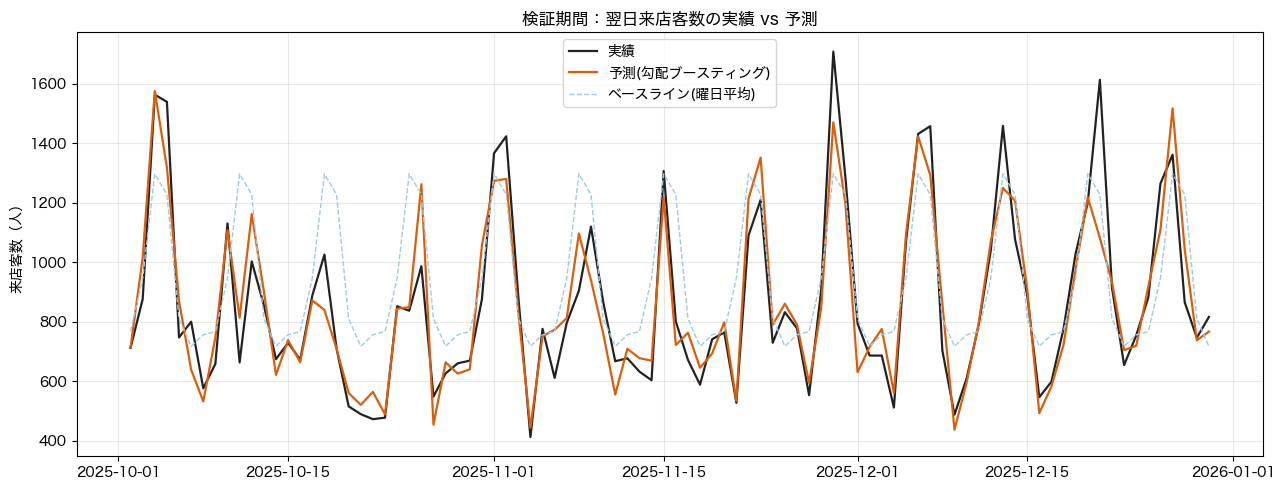

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["date"], y_test.values, label="実績", color="#222", lw=1.6)
ax.plot(test["date"], pred_visit, label="予測(勾配ブースティング)", color="#d95f0e", lw=1.6)
ax.plot(test["date"], base_c, label="ベースライン(曜日平均)", color="#9ecae1", lw=1.0, ls="--")
ax.set_title("検証期間：翌日来店客数の実績 vs 予測")
ax.set_ylabel("来店客数（人）")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 特徴量の重要度（何が来店を動かすか）

Permutation Importance で、各特徴量をシャッフルしたときの精度悪化を測り、重要度を確認します。
フェーズ1で埋め込んだ要因（曜日・人流・SNS先行・販促など）が上位に来れば、狙い通り学習できています。

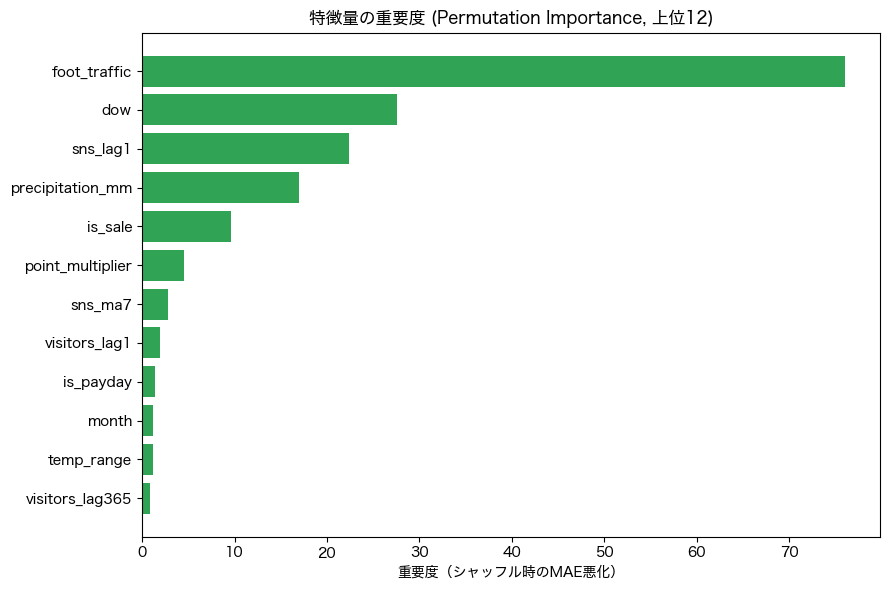

,feature,importance
0,foot_traffic,76.032105
1,dow,27.584119
2,sns_lag1,22.377012
3,precipitation_mm,16.985269
4,is_sale,9.597742
5,point_multiplier,4.545802
6,sns_ma7,2.844299
7,visitors_lag1,1.962268
8,is_payday,1.444266
9,month,1.177049


In [8]:
perm = permutation_importance(
    visit_model, X_test, y_test, n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=1,
)
imp = (
    pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["importance"], color="#31a354")
ax.set_title("特徴量の重要度 (Permutation Importance, 上位12)")
ax.set_xlabel("重要度（シャッフル時のMAE悪化）")
plt.tight_layout()
plt.show()
imp.head(12)

## 7. 売上予測への接続（来店 × 客単価）

来店予測から売上予測へつなげます。**売上 ＝ 来店客数 × 客単価** に分解し、

1. 来店客数 … 上で予測済み（`pred_visit`）
2. 客単価 … 別モデルで予測（曜日・特売・週末・ポイント倍率など、事前に分かる情報から）

を掛け合わせて売上を推定します。比較のため「売上を直接予測するモデル」とも精度を比べます。

In [9]:
# --- 客単価モデル（事前に分かる情報のみ）---
SPEND_FEATURES = ["dow", "month", "is_weekend", "is_holiday", "is_sale", "point_multiplier"]
spend_model = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=4, random_state=42,
)
spend_model.fit(train[SPEND_FEATURES], train["avg_spend"])
pred_spend = spend_model.predict(test[SPEND_FEATURES])

# --- 方式1: 来店予測 × 客単価予測 ---
pred_sales_compose = pred_visit * pred_spend

# --- 方式2: 売上を直接予測 ---
sales_model = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=6, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15, random_state=42,
)
sales_model.fit(X_train, train["sales_amount"])
pred_sales_direct = sales_model.predict(X_test)

y_sales = test["sales_amount"].values
sales_dow_mean = train.groupby("dow")["sales_amount"].mean()
base_sales = test["dow"].map(sales_dow_mean).values

sales_results = pd.DataFrame([
    evaluate("売上 = 来店予測 × 客単価予測", y_sales, pred_sales_compose),
    evaluate("売上を直接予測", y_sales, pred_sales_direct),
    evaluate("ベースライン(曜日平均売上)", y_sales, base_sales),
])
disp2 = sales_results.copy()
for c in ["MAE", "RMSE"]:
    disp2[c] = disp2[c].map(lambda v: f"{v:,.0f}")
for c in ["MAPE(%)", "繁忙日MAPE(%)"]:
    disp2[c] = disp2[c].map(lambda v: f"{v:.1f}")
disp2

,モデル,MAE,RMSE,MAPE(%),繁忙日MAPE(%)
0,売上 = 来店予測 × 客単価予測,"228,015","339,344",9.8,10.3
1,売上を直接予測,"251,305","364,928",10.9,11.8
2,ベースライン(曜日平均売上),"453,976","610,072",22.8,15.3


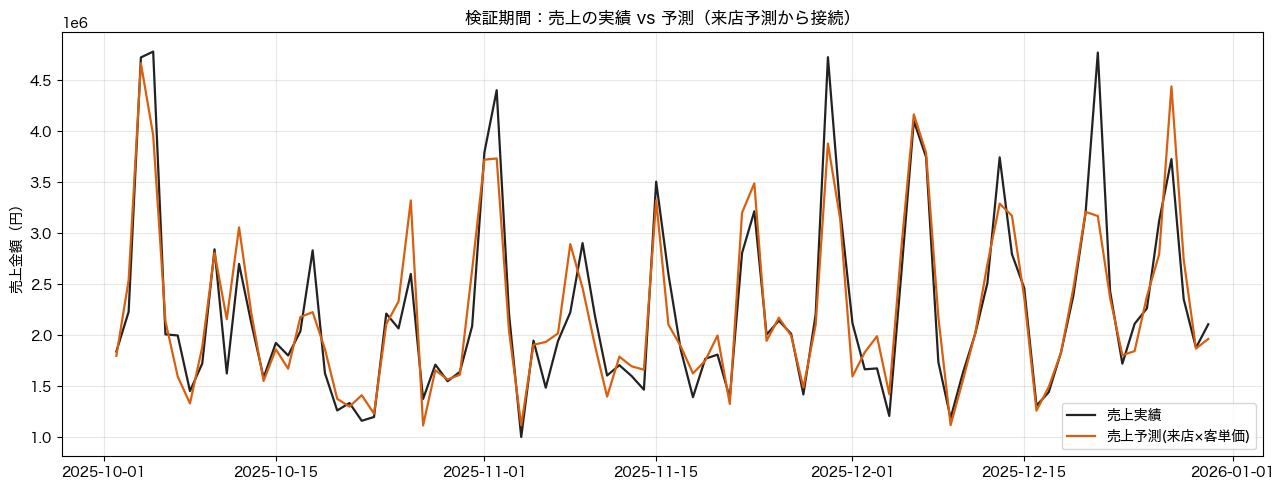

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["date"], y_sales, label="売上実績", color="#222", lw=1.6)
ax.plot(test["date"], pred_sales_compose, label="売上予測(来店×客単価)", color="#d95f0e", lw=1.6)
ax.set_title("検証期間：売上の実績 vs 予測（来店予測から接続）")
ax.set_ylabel("売上金額（円）")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## まとめ

- 翌日の **来店客数** を、予測時点で入手可能な情報のみ（リーク対策済み）で予測した
- 機械学習（勾配ブースティング）が、単純ベースライン（前年同日・移動平均・曜日平均）を上回ることを確認
- 特徴量重要度で、来店を動かす主因（曜日・人流・SNS先行・販促など）を可視化
- 来店予測から **売上予測（来店 × 客単価）** へ接続し、直接予測と精度を比較

### 次フェーズの候補
- **フェーズ4**：会員個人単位の来店・離反（churn）予測（CRM・クーポン施策向け）
- **フェーズ5**：予測結果を解釈し施策を提案する **LLMプロンプト**（例：「明日は特売＋週末で来店増、雨予報のため傘・惣菜を強化」等）
- 実データ接続・複数店舗への拡張